## Model-based Proximal Policy Optimization in the Foraging Environment

Notebook Runtime: ~ 2 mins

### Overview

The Model-Based Proximal Policy Optimization (MBPPO) framework incorporates a world model to simulate future trajectories. In a reset-free environment where the agent only gets "one shot" at a long session, this approach allows the agent to reuse past experiences to "dream" about future outcomes, hopefully leading to increased sample efficiency. It entails the following components.

#### 1. The Dynamics (World) Model

The Dynamics Model acts as a learned simulator. It is trained as an online supervised learner using a History Buffer of real transitions.

* Input: Current state ($s_t$), selected action ($a_t$), and current time ($t$).
* Output: Predicted next state ($s_{t+1}$) via a classification head and predicted reward ($r_t$) via a regression head.
* Role: Enables "imaginary" rollouts by predicting how the environment will respond to the current policy's actions without actually interacting with the real world.

#### 2. Imaginary rollouts (simulating/dreaming)

Periodically, the agent pauses real-world interaction to perform "dreams."

* Seeding: The agent samples several starting points (states and timestamps) from its past history.
* Branching: Starting from these seeds, the agent uses its current policy to select actions and its Dynamics Model to predict outcomes for a fixed horizon ($H$).

#### 3. Mixed-data PPO Update

To maintain stability and avoid "hallucination" (learning from model errors), the update phase uses a mixture of ground-truth and synthetic data.

* Trajectory Pooling: The update batch consists of a mix of Real Sub-trajectories (slices of actual experience) and Simulated Rollouts (dreams).
* Multi-Trajectory GAE: The Generalized Advantage Estimation (GAE) is calculated independently for each trajectory segment. This ensures that temporal dependencies are calculated correctly within a dream but do not "bleed" across disconnected trajectories.
* PPO Optimization: The pooled data is passed through the standard PPO $K$-epoch loop [[link]](https://spinningup.openai.com/en/latest/algorithms/ppo.html)

#### Current Experiments

1. time-agnostic PPO
2. time-aware PPO
3. time-agnostic MBPPO (the dynamics, policy, and value networks are all time-agnostic)
4. time-aware MBPPO (the dynamics, policy, and value networks are all time-aware)

Next: 

* Model-based PPO does not converge to optimal prospective regret. It is very likely that the simulated rollouts are not representative of the actual rollouts. Currently, the dynamics model is an MLP that maps a state, action pair to a next state and a reward. Using a sequence model instead of an MLP may improve the dynamics learning.

In [11]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
from collections import deque

### Time-embedding

In [12]:
# -------------------------
# Time-embedding
# -------------------------

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super(TimeEmbedding, self).__init__()
        self.freqs = (2 * np.pi) / (torch.arange(2, dim + 1, 2))
        self.freqs = self.freqs.unsqueeze(0)

    def forward(self, t):
        t = t.unsqueeze(-1)
        freqs = self.freqs.to(t.device)
        sin = torch.sin(freqs * t)
        cos = torch.cos(freqs * t)

        return torch.cat([sin, cos], dim=-1)

### Buffers

In [13]:
# -------------------------
# History Buffer (For dynamics)
# -------------------------
    
class HistoryBuffer:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, time, reward, log_prob, value, next_state):
        self.buffer.append((state, action, time, reward, log_prob, value, next_state))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    
    def clear(self):
        self.buffer.clear()

# -------------------------
# Rollout Buffer (On-Policy)
# -------------------------
class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.times = []
        self.rewards = []
        self.log_probs = []
        self.values = []

    def push(self, state, action, time, reward, log_prob, value):
        self.states.append(state)
        self.actions.append(action)
        self.times.append(time)
        self.rewards.append(reward)
        self.log_probs.append(log_prob)
        self.values.append(value)

    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.times.clear()
        self.rewards.clear()
        self.log_probs.clear()
        self.values.clear()

### Networks

In [14]:
# -------------------------
# Critic Network (Value Function)
# -------------------------
class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128, t_dim=50, include_time=False):
        super(ValueNetwork, self).__init__()
        input_dim = state_dim + t_dim if include_time else state_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, 1)
        self.include_time = include_time
        self.time_embed = TimeEmbedding(t_dim)
        self.state_dim = state_dim

    def forward(self, state, time):
        state = F.one_hot(state, num_classes=self.state_dim).float()
        if self.include_time:
            x = torch.cat([state, self.time_embed(time)], dim=-1)
        else:
            x = state
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)
    
# -------------------------
# Actor Network (Policy)
# -------------------------
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128, t_dim=50, include_time=False):
        super(PolicyNetwork, self).__init__()
        input_dim = state_dim + t_dim if include_time else state_dim
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, action_dim)
        
        self.include_time = include_time
        self.time_embed = TimeEmbedding(t_dim)
        self.state_dim = state_dim

    def forward(self, state, time):
        state_one_hot = F.one_hot(state, num_classes=self.state_dim).float()
        
        if self.include_time:
            t_emb = self.time_embed(time)
            x = torch.cat([state_one_hot, t_emb], dim=-1)
        else:
            x = state_one_hot
            
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc_out(x)
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        return probs, log_probs

    def get_action_dist(self, state, time):
        """
        Helper for the update phase to get a Categorical distribution
        object directly for entropy and log_prob calculations.
        """
        probs, _ = self.forward(state, time)
        return torch.distributions.Categorical(probs)

# -------------------------
# Dynamics Model
# -------------------------

class DynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256, t_dim=50, include_time=False):
        super(DynamicsModel, self).__init__()
        input_dim = state_dim + action_dim + t_dim if include_time else state_dim + action_dim

        # Input: state (one-hot) + action (one-hot or scalar)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Heads: one for state prediction, one for reward prediction
        self.state_head = nn.Linear(hidden_dim, state_dim)
        self.reward_head = nn.Linear(hidden_dim, 1)

        self.include_time = include_time
        self.time_embed = TimeEmbedding(t_dim)
        self.state_dim = state_dim
        self.action_dim = action_dim

    def forward(self, state, action, time):
        state = F.one_hot(state, num_classes=self.state_dim).float()
        action = F.one_hot(action, num_classes=self.action_dim).float()
        if self.include_time:
            t_emb = self.time_embed(time)
            x = torch.cat([state, action, t_emb], dim=-1)
        else:
            x = torch.cat([state, action], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # Logits for the next state (categorical) and scalar reward
        next_state_logits = self.state_head(x)
        reward = self.reward_head(x)
        return next_state_logits, reward

### PPO

In [15]:
# -------------------------
# PPO Learner
# -------------------------
class PPOLearner:
    def __init__(self, include_time=False, state_dim=7, action_dim=3, 
                 gamma=0.99, lam=0.95, eps_clip=0.2, K_epochs=10, lr=3e-4):
        # GAE parameters
        self.gamma = gamma
        self.lam = lam 

        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.lr = lr

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.include_time = include_time

        self.policy = PolicyNetwork(state_dim, action_dim, include_time=include_time)
        self.critic = ValueNetwork(state_dim, include_time=include_time)
        
        self.optimizer = optim.Adam([
            {'params': self.policy.parameters(), 'lr': lr},
            {'params': self.critic.parameters(), 'lr': lr}
        ])

        self.buffer = RolloutBuffer()

    def select_action(self, state, time, eval_mode=False):
        with torch.no_grad():
            state_t = torch.LongTensor([state])
            time_t = torch.FloatTensor([time])
            probs, log_probs_all = self.policy(state_t, time_t)
            value = self.critic(state_t, time_t)

            if eval_mode:
                action = torch.argmax(probs, dim=-1).item()
                return action
            else:
                # Sample action
                dist = torch.distributions.Categorical(probs)
                action = dist.sample()
                log_prob = log_probs_all[0, action.item()]
                return action.item(), log_prob.item(), value.item()
            
    def run_current_policy(self, env, state, time, horizon):
        curr_state = state
        curr_time = time
        trajectory = [curr_state]
        rewards = [env._get_current_reward(curr_state, curr_time)]
        for _ in range(horizon):
            action = self.select_action(curr_state, curr_time, eval_mode=True)
            curr_state = env.get_next_state(state=curr_state, action=action)
            curr_time += 1
            trajectory.append(curr_state)
            rewards.append(env._get_current_reward(curr_state, curr_time))
        return trajectory, rewards

    def update(self, next_state, next_time):
        # 1. Prepare data from buffer
        states = torch.LongTensor(self.buffer.states)
        actions = torch.LongTensor(self.buffer.actions)
        times = torch.FloatTensor(self.buffer.times)
        old_log_probs = torch.FloatTensor(self.buffer.log_probs)
        values = torch.FloatTensor(self.buffer.values)
        rewards = self.buffer.rewards

        # 2. Compute GAE and Returns
        with torch.no_grad():
            # Bootstrap
            next_value = self.critic(torch.LongTensor([next_state]), torch.FloatTensor([next_time])).item()
            
            advantages = []
            gae = 0
            for i in reversed(range(len(rewards))):
                # Delta is the temporal difference error
                delta = rewards[i] + self.gamma * next_value - values[i]
                gae = delta + self.gamma * self.lam * gae
                advantages.insert(0, gae)
                next_value = values[i]
            
            advantages = torch.FloatTensor(advantages)
            returns = advantages + values # rewards-to-go
            # Normalize advantages for stability
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # 3. Optimization Loop (K Epochs)
        for _ in range(self.K_epochs):
            # Get current policy distribution and values
            probs, log_probs_all = self.policy(states, times)
            curr_values = self.critic(states, times).squeeze()
            
            curr_log_probs = log_probs_all.gather(1, actions.unsqueeze(1)).squeeze()

            # Compute the entropy bonus (encourage the policy to explore more by maximizing entropy)
            dist = torch.distributions.Categorical(probs)
            entropy = dist.entropy().mean()

            # PPO Ratio calculation
            ratio = torch.exp(curr_log_probs - old_log_probs)

            # Clipped Surrogate Objective
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            
            # Loss composition: Policy Loss - Entropy Bonus + Value Loss
            policy_loss = -torch.min(surr1, surr2).mean()
            value_loss = F.mse_loss(curr_values, returns)
            
            loss = policy_loss + 0.5 * value_loss - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        self.buffer.clear()

### Model-based PPO

Inherits from the PPO class.

In [16]:
class MBPPOLearner(PPOLearner):
    def __init__(
        self,
        imagination_horizon=10,
        imagination_batch=64,
        *args,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.imagination_horizon = imagination_horizon
        self.imagination_batch = imagination_batch

        self.world_model = DynamicsModel(
            state_dim=self.state_dim,
            action_dim=self.action_dim,
            include_time=self.include_time
        )
        self.wm_optimizer = optim.Adam(
            self.world_model.parameters(), 
            lr=self.lr
        )
        
        self.history = HistoryBuffer()
        self.curr_policy_history = HistoryBuffer()

    def get_next_state_and_reward(self, state, action, time):
        with torch.no_grad():
            state_t = torch.LongTensor([state])
            action_t = torch.LongTensor([action])
            time_t = torch.FloatTensor([time])
            next_state_logits, reward = self.world_model(state_t, action_t, time_t)
            next_state = torch.argmax(next_state_logits, dim=-1).item()
            # probs = F.softmax(next_state_logits, dim=-1)
            # dist = torch.distributions.Categorical(probs)
            # next_state = dist.sample()
        return next_state, reward

    def simulate_rollouts(self):
        """
        Collects multiple synthetic trajectories into the buffer, 
        then performs a single PPO update on the whole batch.

        N (num trajectories) x H (horizon)
        """
        if len(self.curr_policy_history.buffer) < self.imagination_batch:
            return

        # 1. Sample all starting points at once
        seeds = self.curr_policy_history.sample(self.imagination_batch)
        
        all_dream_data = [] # To store (s, a, t, r, lp, v) per trajectory

        for seed in seeds:
            trajectory = []
            curr_state = seed[-1] # start from the 'next_state' of the history
            curr_time = seed[2] + 1
            
            for _ in range(self.imagination_horizon):
                # pick action using the current policy
                action, log_prob, value = self.select_action(curr_state, curr_time)
                
                # Predict next state and reward
                next_state, reward = self.get_next_state_and_reward(curr_state, action, curr_time)
                
                # Store temporarily
                trajectory.append((curr_state, action, curr_time, reward, log_prob, value))
                
                curr_state = next_state
                curr_time += 1
            
            # Add this dream to the master list
            all_dream_data.append((trajectory, curr_state, curr_time))

        return all_dream_data
    
    def prepare_mixed_data(self):
        real_segment = list(self.curr_policy_history.buffer)
        horizon = self.imagination_horizon

        all_trajectories = []

        for i in range(0, len(real_segment) - horizon, horizon):
            chunk = real_segment[i : i + horizon]
            final_s = real_segment[i + horizon][0] # state of next step
            final_t = real_segment[i + horizon][2] # time of next step
            all_trajectories.append((chunk, final_s, final_t))

        all_trajectories.extend(self.simulate_rollouts())
        return all_trajectories

    def train_dynamics(self, batch_size=64, epochs=5):
        if len(self.history.buffer) < batch_size:
            return 0.0, 0.0 # Not enough data yet

        self.world_model.train()
        total_state_loss = 0
        total_reward_loss = 0

        for _ in range(epochs):
            # Sample a random batch of (s, a, r, s_next, t)
            batch = self.history.sample(batch_size)
            
            states = torch.LongTensor([b[0] for b in batch])
            actions = torch.LongTensor([b[1] for b in batch])
            rewards = torch.FloatTensor([b[4] for b in batch]).unsqueeze(-1)
            next_states = torch.LongTensor([b[-1] for b in batch])
            times = torch.FloatTensor([b[2] for b in batch])

            # Predict
            state_logits, pred_rewards = self.world_model(states, actions, times)

            # Losses: CrossEntropy for discrete states, MSE for scalar rewards
            state_loss = F.cross_entropy(state_logits, next_states)
            reward_loss = F.mse_loss(pred_rewards, rewards)
            
            loss = state_loss + reward_loss

            self.wm_optimizer.zero_grad()
            loss.backward()
            self.wm_optimizer.step()
            
            total_state_loss += state_loss.item()
            total_reward_loss += reward_loss.item()

        return total_state_loss / epochs, total_reward_loss / epochs

    def update(self, all_dream_data):
        """
        Computes GAE for each trajectory independently, 
        then pools them for the K-epoch PPO optimization.

        Each trajectory has 
        (curr_state, action, curr_time, reward, log_prob, value)
        """
        all_states, all_actions, all_times = [], [], []
        all_old_log_probs, all_values, all_returns, all_advantages = [], [], [], []

        for trajectory, final_state, final_time in all_dream_data:
            # Extract data for this specific dream
            states = torch.LongTensor([t[0] for t in trajectory])
            actions = torch.LongTensor([t[1] for t in trajectory])
            times = torch.FloatTensor([t[2] for t in trajectory])
            rewards = [t[3] for t in trajectory]
            old_log_probs = torch.FloatTensor([t[4] for t in trajectory])
            values = torch.FloatTensor([t[5] for t in trajectory])

            # Bootstrap from the end of THIS dream
            with torch.no_grad():
                next_value = self.critic(torch.LongTensor([final_state]), torch.FloatTensor([final_time])).item()
                
                traj_advantages = []
                gae = 0
                for i in reversed(range(len(rewards))):
                    delta = rewards[i] + self.gamma * next_value - values[i]
                    gae = delta + self.gamma * self.lam * gae
                    traj_advantages.insert(0, gae)
                    next_value = values[i]
                
                traj_advantages = torch.FloatTensor(traj_advantages)
                traj_returns = traj_advantages + values

            # Pool the processed data
            all_states.append(states)
            all_actions.append(actions)
            all_times.append(times)
            all_old_log_probs.append(old_log_probs)
            all_values.append(values)
            all_returns.append(traj_returns)
            all_advantages.append(traj_advantages)

        # Concatenate everything into one giant batch for PPO epochs
        states = torch.cat(all_states)
        actions = torch.cat(all_actions)
        times = torch.cat(all_times)
        old_log_probs = torch.cat(all_old_log_probs)
        returns = torch.cat(all_returns)
        advantages = torch.cat(all_advantages)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Now run your K_epochs loop using S, A, T, LP, RET, ADV
        for _ in range(self.K_epochs):
            # Get current policy distribution and values
            probs, log_probs_all = self.policy(states, times)
            curr_values = self.critic(states, times).squeeze()
            
            curr_log_probs = log_probs_all.gather(1, actions.unsqueeze(1)).squeeze()

            # Compute the entropy bonus (encourage the policy to explore more by maximizing entropy)
            dist = torch.distributions.Categorical(probs)
            entropy = dist.entropy().mean()

            # PPO Ratio calculation
            ratio = torch.exp(curr_log_probs - old_log_probs)

            # Clipped Surrogate Objective
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            
            # Loss composition: Policy Loss - Entropy Bonus + Value Loss
            policy_loss = -torch.min(surr1, surr2).mean()
            value_loss = F.mse_loss(curr_values, returns)
            
            loss = policy_loss + 0.5 * value_loss - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

### Foraging Environment

In [17]:
# -------------------------
# Foraging Environment
# -------------------------

class ForagingEnv:
    def __init__(
        self,
        initial_reward: int = 10,
        decay_rate: float = 0.6,
        window_size: int = 10,
        session_length: int = 500000
    ):
        self.initial_reward = initial_reward
        self.decay_rate = decay_rate
        self.window_size = window_size
        self.period = 2 * window_size
        self.session_length = session_length

        self.patch_A = 1
        self.patch_B = 5

        self.rewards_in_session = self._compute_session_rewards()

        self.action_space = [-1, 0, 1]  # left, stay, right
        self.reset()
    
    def reset(self):
        self.current_step = 0
        self.state = 1  # Start at state 1
        return self.state
    
    def get_next_state(self, action, state=None):
        action = self.action_space[action]  # map action index to actual action
        state = self.state if not state else state 
        next_state = state + action
        if state == 0 and next_state < 0:
            next_state = 0
        if state == 6 and next_state > 6:
            next_state = 6
        return next_state
    
    def step(self, action):
        # Action: -1 (left), 0 (stay), +1 (right)
        reward = self._get_current_reward(self.state, self.current_step)
        next_state = self.get_next_state(action)
        self.state = next_state
        self.current_step += 1
        return next_state, reward
    
    def get_state(self):
        return self.state

    def get_time(self):
        return self.current_step
    
    def run_optimal_policy(self, state, time, horizon):
        curr_time = time
        curr_state = state
        trajectory = [curr_state]
        rewards = [self._get_current_reward(curr_state, curr_time)]
        if horizon: 
            for _ in range(horizon):
                target = self._get_current_target(curr_time)
                if curr_state > target:
                    curr_state -= 1
                elif curr_state < target:
                    curr_state += 1
                curr_time += 1
                trajectory.append(curr_state)
                rewards.append(self._get_current_reward(curr_state, curr_time))
        return trajectory, rewards
    
    def _compute_session_rewards(self):
        rewards_per_window = self.initial_reward * self.decay_rate ** np.arange(self.window_size)
        rewards_per_window = rewards_per_window.tolist()
        num_windows, remainder = divmod(self.session_length, self.window_size)
        return rewards_per_window * num_windows + rewards_per_window[:remainder] 

    def _get_current_reward(self, state, time):
        phase = time % self.period
        if state == self.patch_A and phase < self.window_size:
            return self.rewards_in_session[time]
        elif state == self.patch_B and phase >= self.window_size:
            return self.rewards_in_session[time]
        else:
            return 0.0
        
    def _get_current_target(self, time):
        phase = time % self.period
        q1 = self.period // 4
        q3 = self.period // 4 * 3
        if phase <= q1: 
            return self.patch_A
        elif phase > q3:
            return self.patch_A
        else:
            return self.patch_B

### Evaluation

In [18]:
def get_normalized_future_rewards(rewards, gamma):
    Y = np.zeros_like(rewards, dtype=float)
    H = len(rewards)
    
    # Pre-calculate powers of gamma up to the maximum possible horizon
    gammas = gamma ** np.arange(H)

    for t in range(H - 1):
        # The number of steps remaining after time t
        L = H - 1 - t
        
        # Slice the rewards and weights
        future_rewards = rewards[t+1:]
        weights = gammas[:L]
        
        # Normalize and compute the weighted sum
        Y[t] = np.dot(weights, future_rewards) / weights.sum()

    return Y

def evaluate(learner, env, state, time, eval_period=100, gamma=0.5):
    _, pred_rewards = learner.run_current_policy(env, state, time, eval_period)
    _, optimal_rewards = env.run_optimal_policy(state, time, eval_period)

    pred_prewards = get_normalized_future_rewards(pred_rewards[1:], gamma)
    optimal_prewards = get_normalized_future_rewards(optimal_rewards[1:], gamma)
    pregret = np.mean(optimal_prewards - pred_prewards)
    return pregret

### Experiment

In [19]:
def run_replicate(
    include_time=False,
    dynamics_update_interval=512,
    policy_update_interval=1024,
    num_seeds=16, # number of "dreams"
    horizon=32, # how far are we dreaming ahead
    eval_period=100,
    terminal_time=100000
):
    env = ForagingEnv()
    learner = MBPPOLearner(
        imagination_batch=num_seeds,
        imagination_horizon=horizon,
        include_time=include_time
    )

    t_list = []
    pregret_list = []

    progress_bar = tqdm(range(0, terminal_time))
    for t in progress_bar:
        # get current state
        state = env.get_state()

        # evaluate
        if (t + 1) % eval_period == 0:
            pregret = evaluate(learner, env, state, t)
            pregret_list.append(pregret)
            # print(f"Time {t+1}, Pregret: {pregret:.3f}")
            t_list.append(t+1)

        # --- collect data from the current policy ---

        # Select action
        action, log_prob, value = learner.select_action(state, t)

        # Step in environment
        next_state, reward = env.step(action)

        # Store transition
        learner.history.push(state, action, t, reward, log_prob, value, next_state)
        learner.curr_policy_history.push(state, action, t, reward, log_prob, value, next_state)

        # --- update world model --- 
        if (t + 1) % dynamics_update_interval == 0:
            # update the world model
            learner.train_dynamics()

        # --- update policy --- 
        if (t + 1) % policy_update_interval == 0:
            # generated simulated trajectories using the world model and the current policy
            # imagined_data = learner.simulate_rollouts()
            mixed_data = learner.prepare_mixed_data()

            # run the PPO update on the simulated data
            # learner.update(imagined_data)
            learner.update(mixed_data)

            # clear the current policty history buffer
            learner.curr_policy_history.clear()

    pregret_list = np.array(pregret_list)
    t_list = np.array(t_list)
    return pregret_list, t_list

### Run the Experiment

In [20]:
num_reps = 10

results_notime = Parallel(n_jobs=10)(delayed(run_replicate)(include_time=False) for _ in range(num_reps))
results_time = Parallel(n_jobs=10)(delayed(run_replicate)(include_time=True) for _ in range(num_reps))

pregrets_notime = []
for pregret_list, t_list in results_notime:
    pregrets_notime.append(pregret_list)

pregrets_time = []
for pregret_list, t_list in results_time:
    pregrets_time.append(pregret_list)

100%|██████████| 100000/100000 [00:59<00:00, 1672.59it/s]


### Plots

In [21]:
def get_median_and_iqr(pregret_list):
    median = np.median(pregret_list, axis=0)
    q1 = np.percentile(pregret_list, 25, axis=0)
    q3 = np.percentile(pregret_list, 75, axis=0)
    return median, q1, q3

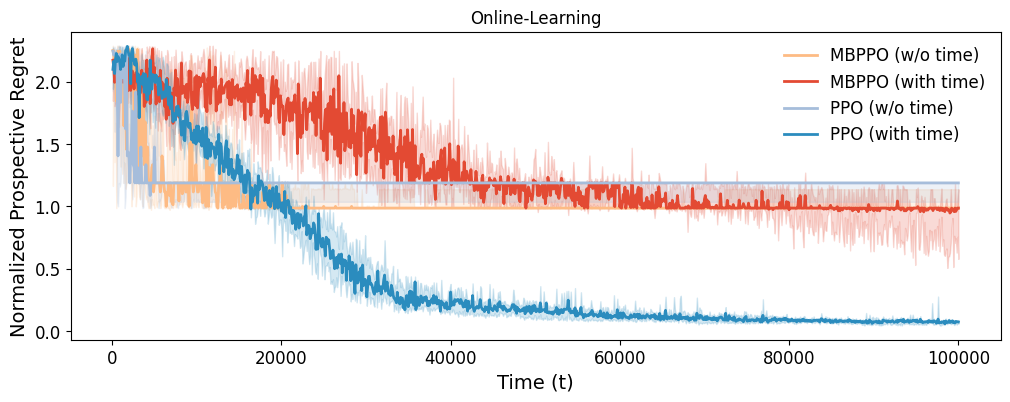

In [25]:
fig, ax = plt.subplots(figsize=(12, 4))
lw=2
fontsize = 14

color = "#fdbb84"
median, q1, q3 = get_median_and_iqr(pregrets_notime)
ax.plot(t_list, median, label='MBPPO (w/o time)', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)

color = "#e34a33"
median, q1, q3 = get_median_and_iqr(pregrets_time)
ax.plot(t_list, median, label='MBPPO (with time)', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)

# Plot the PPO results as well
# ---------------------------------
results = np.load(f"../results/RL/online_pregrets_ppo.npz")
ppo_pregrets_notime = results['pregret_list_notime']
ppo_pregrets_time = results['pregret_list_time']
t_list = results['t_list']

color = "#a6bddb"
median, q1, q3 = get_median_and_iqr(ppo_pregrets_notime)
ax.plot(t_list, median, label='PPO (w/o time)', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)

color = "#2b8cbe"
median, q1, q3 = get_median_and_iqr(ppo_pregrets_time)
ax.plot(t_list, median, label='PPO (with time)', lw=lw, color=color)
ax.fill_between(t_list, q1, q3, alpha=0.2, color=color)
# ---------------------------------

ax.set_xlabel("Time (t)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
ax.legend(fontsize=fontsize-2, frameon=False)
ax.set_title("Online-Learning")
plt.show()